In [1]:
import pandas as pd
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import contextily as cx
from matplotlib.colors import LinearSegmentedColormap

In [2]:
data_path = "/Users/martina/Università/esami_da_fare/complex_networks/sea-duck-network/centroids_k28_definitivo.csv"
# Leggi il file CSV
df_full = pd.read_csv(data_path, sep=';')

# Mostra le prime righe
df_full.head()

# Filtra solo Black Scoter
df = df_full[df_full['species'] == 'SUSC'].copy()

BETWEENNESS CENTRALITY - Surf Scoter

1. Dati caricati...
   ✓ Caricati 936 centroids
   ✓ Specie presenti: 1
   ✓ Cluster: 20

2. Filtraggio movimenti validi...
   ✓ Movimenti validi: 804

3. Calcolo pesi degli archi (somma wt_sp per ogni link)...
   ✓ Link unici nella rete: 139
   ✓ Peso minimo: 3.4679
   ✓ Peso massimo: 228.8846
   ✓ Peso medio: 20.0592

4. Costruzione grafo con α = 0.5...
   ✓ Nodi nel grafo: 20
   ✓ Archi nel grafo: 139

5. Calcolo betweenness centrality...
   (questo può richiedere qualche secondo...)
   ✓ Betweenness calcolata per 20 cluster

RISULTATI - TOP 10 CLUSTER PER BETWEENNESS CENTRALITY - SUSC
 cluster  betweenness_centrality
      13                   125.0
      15                   107.0
      19                    59.0
      23                    53.0
       7                    25.0
       5                    18.0
      20                    17.0
      24                    17.0
      14                    11.0
      16                     1.0

ST

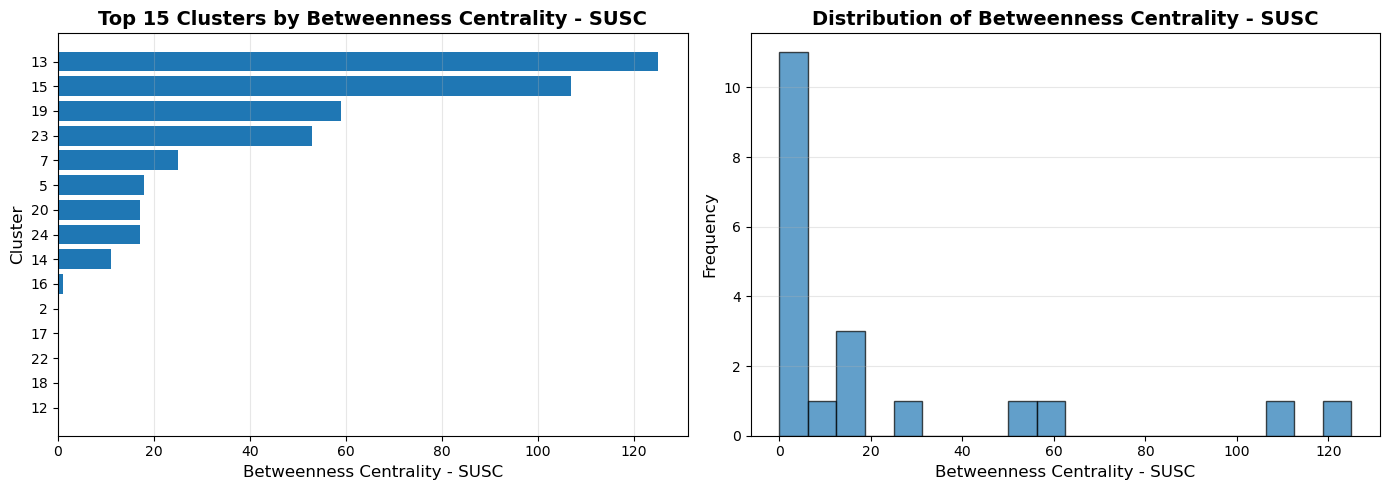

In [5]:
def calculate_global_betweenness(df, alpha=0.5):
    """
    Calcola la betweenness centrality per Surf Scoter seguendo Lamb et al. 2019

    alpha : float (default=0.5)
        Parametro di Opsahl et al. 2010 per bilanciare numero e peso delle connessioni
    
    Returns:
    --------
    bc_df : DataFrame
        DataFrame con cluster e betweenness centrality ordinato
    G : networkx.DiGraph
        Grafo della rete
    edge_weights : DataFrame
        DataFrame con i pesi degli archi
    """
    
    print("="*60)
    print("BETWEENNESS CENTRALITY - Surf Scoter")
    print("="*60)
    
    # 1. Info sui dati (df è già caricato!)
    print("\n1. Dati caricati...")
    print(f"   ✓ Caricati {len(df)} centroids")
    print(f"   ✓ Specie presenti: {df['species'].nunique()}")
    print(f"   ✓ Cluster: {df['cluster'].nunique()}")
    
    # 2. Rimuovi righe dove next_cluster è NaN (ultimo centroide per individuo)
    print("\n2. Filtraggio movimenti validi...")
    df_valid = df[df['next_cluster'].notna()].copy()
    df_valid['next_cluster'] = df_valid['next_cluster'].astype(int)
    print(f"   ✓ Movimenti validi: {len(df_valid)}")
    
    # 3. Calcola i pesi degli archi (GLOBAL: tutte le specie)
    print("\n3. Calcolo pesi degli archi (somma wt_sp per ogni link)...")
    edge_weights = df_valid.groupby(['cluster', 'next_cluster'])['wt_sp'].sum().reset_index()
    edge_weights.columns = ['source', 'target', 'weight']
    print(f"   ✓ Link unici nella rete: {len(edge_weights)}")
    print(f"   ✓ Peso minimo: {edge_weights['weight'].min():.4f}")
    print(f"   ✓ Peso massimo: {edge_weights['weight'].max():.4f}")
    print(f"   ✓ Peso medio: {edge_weights['weight'].mean():.4f}")
    
    # 4. Costruisci il grafo diretto con pesi trasformati secondo Opsahl et al. 2010
    print(f"\n4. Costruzione grafo con α = {alpha}...")
    G = nx.DiGraph()
    
    for _, row in edge_weights.iterrows():
        source = int(row['source'])
        target = int(row['target'])
        weight = row['weight']
        
        # Costo per shortest path secondo Opsahl: 1 / (weight^α)
        distance = 1.0 / (weight ** alpha)
        
        G.add_edge(source, target, weight=weight, distance=distance)
    
    print(f"   ✓ Nodi nel grafo: {G.number_of_nodes()}")
    print(f"   ✓ Archi nel grafo: {G.number_of_edges()}")
    
    # 5. Calcola betweenness centrality
    print("\n5. Calcolo betweenness centrality...")
    print("   (questo può richiedere qualche secondo...)")
    
    # Usa 'distance' come peso per shortest path
    betweenness = nx.betweenness_centrality(
        G, 
        weight='distance',  # Usa il costo trasformato
        normalized=False     # Normalizza per (n-1)(n-2)
    )
    
    # Converti in DataFrame e ordina
    bc_df = pd.DataFrame([
        {'cluster': node, 'betweenness_centrality': bc}
        for node, bc in betweenness.items()
    ]).sort_values('betweenness_centrality', ascending=False)
    
    print(f"   ✓ Betweenness calcolata per {len(bc_df)} cluster")
    
    # 6. Stampa risultati
    print("\n" + "="*60)
    print("RISULTATI - TOP 10 CLUSTER PER BETWEENNESS CENTRALITY - SUSC")
    print("="*60)
    print(bc_df.head(10).to_string(index=False))
    
    print("\n" + "="*60)
    print("STATISTICHE BETWEENNESS CENTRALITY - SUSC")
    print("="*60)
    print(f"Min:    {bc_df['betweenness_centrality'].min():.6f}")
    print(f"Max:    {bc_df['betweenness_centrality'].max():.6f}")
    print(f"Mean:   {bc_df['betweenness_centrality'].mean():.6f}")
    print(f"Median: {bc_df['betweenness_centrality'].median():.6f}")
    print(f"Std:    {bc_df['betweenness_centrality'].std():.6f}")
    
    return bc_df, G, edge_weights


def plot_betweenness_results(bc_df, save_path=None):
    """
    Crea visualizzazioni della betweenness centrality
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Barplot dei top cluster
    ax1 = axes[0]
    top_clusters = bc_df.head(15)
    ax1.barh(top_clusters['cluster'].astype(str), top_clusters['betweenness_centrality'])
    ax1.set_xlabel('Betweenness Centrality - SUSC', fontsize=12)
    ax1.set_ylabel('Cluster', fontsize=12)
    ax1.set_title('Top 15 Clusters by Betweenness Centrality - SUSC', fontsize=14, fontweight='bold')
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3)
    
    # Plot 2: Distribuzione
    ax2 = axes[1]
    ax2.hist(bc_df['betweenness_centrality'], bins=20, edgecolor='black', alpha=0.7)
    ax2.set_xlabel('Betweenness Centrality - SUSC', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.set_title('Distribution of Betweenness Centrality - SUSC', fontsize=14, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    
    plt.show()


# ============================================================================
# ESEGUI QUI
# ============================================================================

# Calcola betweenness centrality (usa il df già caricato sopra!)
bc_df, G, edge_weights = calculate_global_betweenness(df, alpha=0.5)

# Cartella dove salvare i risultati (stessa del CSV)
base_path = "/Users/martina/Università/esami_da_fare/complex_networks/sea-duck-network/"

# Crea plot
plot_betweenness_results(bc_df, save_path=base_path + "betweenness_global_plot.png")



Calcolo coordinate medie per ogni cluster...
Cluster con coordinate: 20

✓ Mappa di sfondo aggiunta!


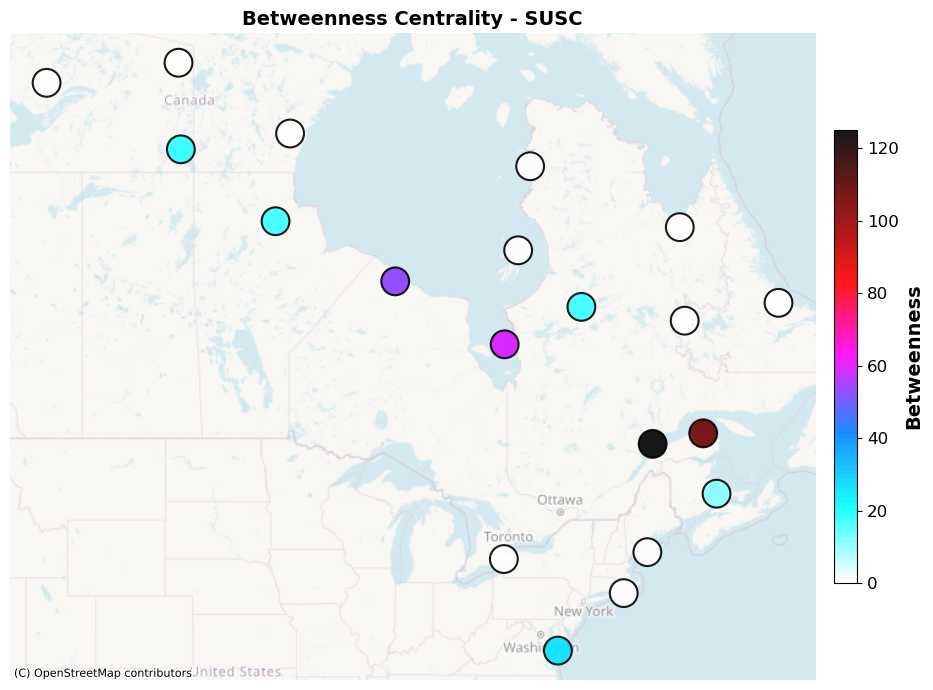


TOP 5 CLUSTER PER BETWEENNESS - SUSC
Cluster 13: BC=125.0, Lat=48.74, Lon=-68.99
Cluster 15: BC=107.0, Lat=49.24, Lon=-65.36
Cluster 19: BC=59.0, Lat=53.24, Lon=-79.63
Cluster 23: BC=53.0, Lat=55.86, Lon=-87.50
Cluster 7: BC=25.0, Lat=37.99, Lon=-75.80


In [6]:

def plot_betweenness_map(df, bc_df, save_path=None):
    """
    Crea mappa geografica con betweenness centrality come nella Fig 4c di Lamb
    
    Parameters:
    -----------
    df : DataFrame
        DataFrame con i centroids (deve avere: cluster, lat, lon)
    bc_df : DataFrame
        DataFrame con betweenness centrality per cluster
    save_path : str (optional)
        Path per salvare la figura
    """
    
    # 1. Calcola coordinate medie per ogni cluster
    print("Calcolo coordinate medie per ogni cluster...")
    cluster_coords = df.groupby('cluster').agg({
        'lat': 'mean',
        'lon': 'mean'
    }).reset_index()
    
    # 2. Merge con betweenness centrality
    cluster_data = cluster_coords.merge(bc_df, on='cluster')
    
    print(f"Cluster con coordinate: {len(cluster_data)}")
    
    # 3. Converti coordinate in Web Mercator (per contextily)
    from pyproj import Transformer
    transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
    
    x_coords, y_coords = transformer.transform(
        cluster_data['lon'].values,
        cluster_data['lat'].values
    )
    
    cluster_data['x_web'] = x_coords
    cluster_data['y_web'] = y_coords
    
    # 4. Setup figura
    fig, ax = plt.subplots(figsize=(10,7))
    
    # 5. Colormap simile al paper (giallo -> arancione -> viola -> nero)
    colors = ['#FFFFFF', '#00FFFF', '#0080FF', '#FF00FF', '#FF0000', '#800000', '#000000']
    n_bins = 100
    cmap = LinearSegmentedColormap.from_list('betweenness', colors, N=n_bins)
    
    # 6. Plot dei punti
    bc_values = cluster_data['betweenness_centrality'].values
    
    scatter = ax.scatter(
        cluster_data['x_web'],
        cluster_data['y_web'],
        c=bc_values,
        s=400,  # Dimensione punti
        cmap=cmap,
        vmin=0,
        vmax=bc_values.max(),
        edgecolors='black',
        linewidths=1.5,
        zorder=10,
        alpha=0.9
    )
    
    # 7. Aggiungi mappa di sfondo
    try:
        cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.5, zorder=1)
        print("\n✓ Mappa di sfondo aggiunta!")
    except Exception as e:
        print(f"\nNota: Mappa non disponibile: {e}")
        ax.set_facecolor('#E8F4F8')
    
    # 8. Colorbar con stile del paper
    cbar = plt.colorbar(scatter, ax=ax, orientation='vertical', 
                        pad=0.02, shrink=0.7, aspect=20)
    cbar.set_label('Betweenness', fontsize=14, fontweight='bold')
    cbar.ax.tick_params(labelsize=12)
    ax.set_title('Betweenness Centrality - SUSC', fontsize=14, fontweight='bold')
    
    # 10. Rimuovi assi
    ax.set_axis_off()
    
    plt.tight_layout()
    

    plt.show()
    
    # Stampa info sui top cluster
    print("\n" + "="*60)
    print("TOP 5 CLUSTER PER BETWEENNESS - SUSC")
    print("="*60)
    top5 = cluster_data.nlargest(5, 'betweenness_centrality')
    for _, row in top5.iterrows():
        print(f"Cluster {int(row['cluster'])}: BC={row['betweenness_centrality']:.1f}, "
              f"Lat={row['lat']:.2f}, Lon={row['lon']:.2f}")


# ============================================================================
# ESEGUI QUI
# ============================================================================

# Crea la mappa (usa df e bc_df che hai già)
base_path = "/Users/martina/Università/esami_da_fare/complex_networks/sea-duck-network/"

plot_betweenness_map(
    df=df,
    bc_df=bc_df,
    save_path=base_path + "betweenness_map_fig4c.png"
)

INDEGREE & OUTDEGREE CENTRALITY

1. Filtraggio movimenti validi...
   ✓ Movimenti validi: 804

2. Calcolo pesi degli archi...
   ✓ Link unici: 139

3. Applicazione trasformazione α = 0.5...

4. Costruzione grafo...
   ✓ Nodi: 20
   ✓ Archi: 139

5. Calcolo indegree e outdegree centrality...
   ✓ Calcolato per 20 cluster

TOP 10 CLUSTER PER INDEGREE
 cluster  indegree
      13 70.844849
      15 64.946956
       7 55.694179
      14 48.163887
       8 37.465125
      19 35.671444
      20 32.340885
      16 29.242486
       9 28.138005
      22 27.662629

TOP 10 CLUSTER PER OUTDEGREE
 cluster  outdegree
      15  79.955730
      13  61.663959
      14  56.784358
       7  50.359618
       8  37.125175
      16  34.064374
      19  33.606195
      20  32.116308
       9  27.265073
      18  23.483565

STATISTICHE

INDEGREE:
  Min:    1.86
  Max:    70.84
  Mean:   26.41
  Median: 25.29

OUTDEGREE:
  Min:    1.86
  Max:    79.96
  Mean:   26.41
  Median: 23.05


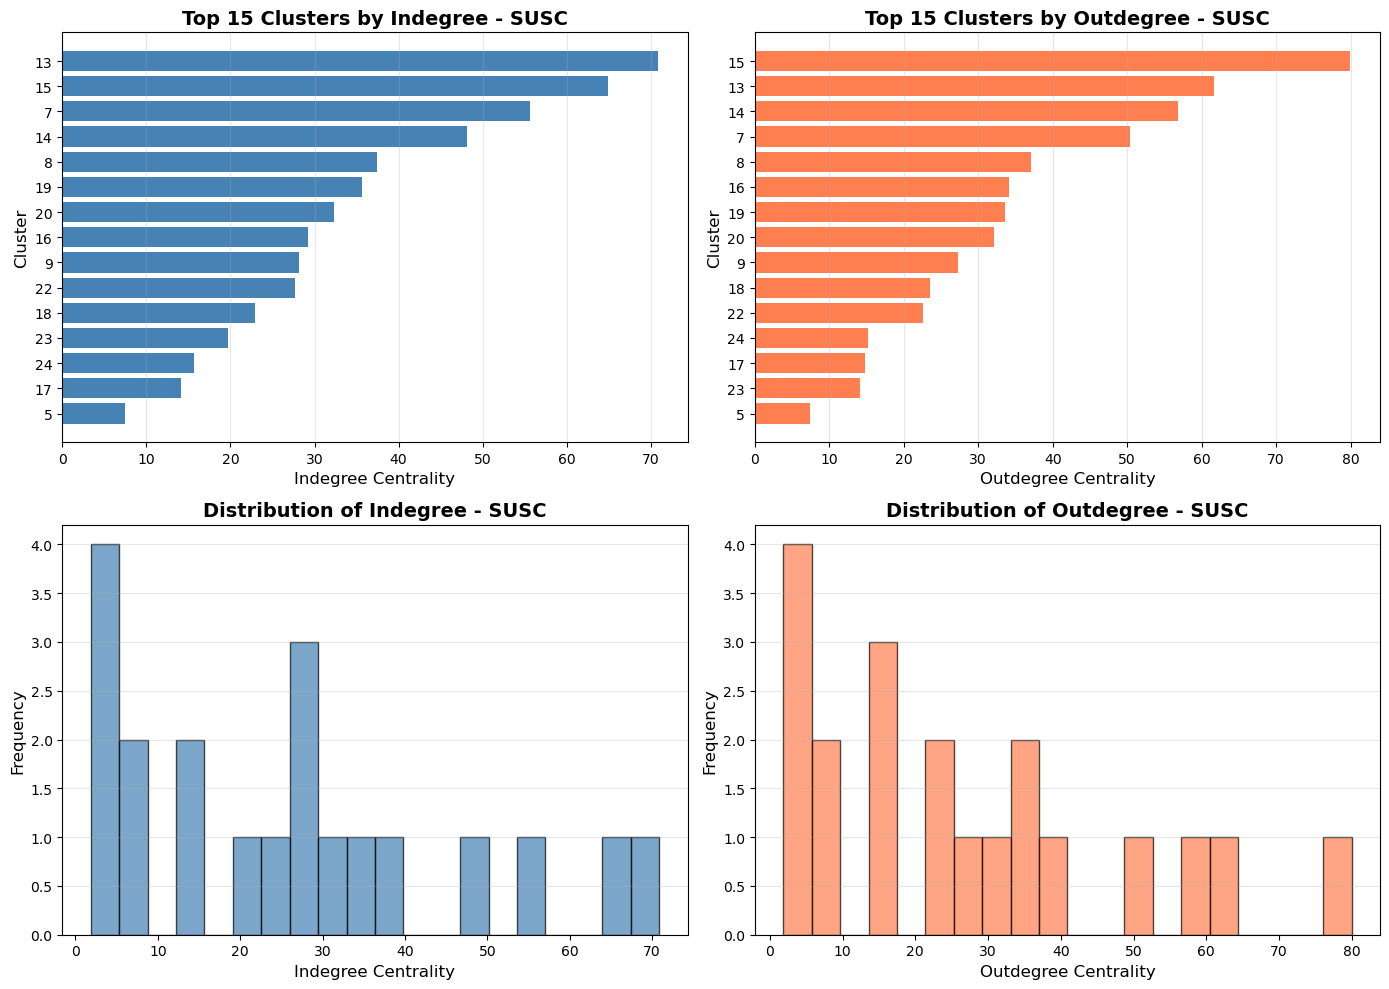

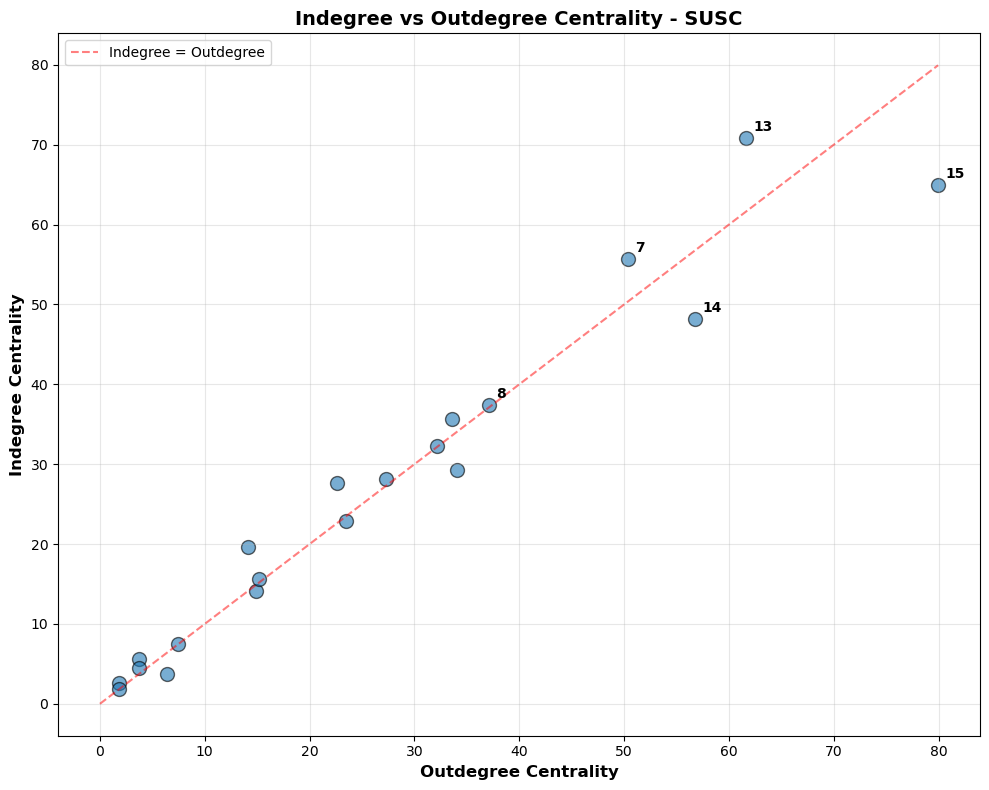


✅ FATTO! Indegree e Outdegree calcolati!


In [6]:
def calculate_degree_centrality(df, alpha=0.5):
    """
    Calcola indegree e outdegree centrality seguendo Lamb et al. 2019
    
    Parameters:
    -----------
    df : DataFrame
        DataFrame con i centroids
    alpha : float (default=0.5)
        Parametro di Opsahl et al. 2010
    
    Returns:
    --------
    degree_df : DataFrame
        DataFrame con cluster, indegree, outdegree
    G : networkx.DiGraph
        Grafo della rete
    edge_weights : DataFrame
        Pesi degli archi
    """
    
    print("="*60)
    print("INDEGREE & OUTDEGREE CENTRALITY")
    print("="*60)
    
    # 1. Filtra movimenti validi
    print("\n1. Filtraggio movimenti validi...")
    df_valid = df[df['next_cluster'].notna()].copy()
    df_valid['next_cluster'] = df_valid['next_cluster'].astype(int)
    print(f"   ✓ Movimenti validi: {len(df_valid)}")
    
    # 2. Calcola pesi degli archi (somma wt_sp)
    print("\n2. Calcolo pesi degli archi...")
    edge_weights = df_valid.groupby(['cluster', 'next_cluster'])['wt_sp'].sum().reset_index()
    edge_weights.columns = ['source', 'target', 'weight']
    print(f"   ✓ Link unici: {len(edge_weights)}")
    
    # 3. Applica trasformazione α di Opsahl
    print(f"\n3. Applicazione trasformazione α = {alpha}...")
    edge_weights['weight_alpha'] = edge_weights['weight'] ** alpha
    
    # 4. Costruisci grafo
    print("\n4. Costruzione grafo...")
    G = nx.DiGraph()
    
    for _, row in edge_weights.iterrows():
        G.add_edge(
            int(row['source']), 
            int(row['target']), 
            weight=row['weight'],
            weight_alpha=row['weight_alpha']
        )
    
    print(f"   ✓ Nodi: {G.number_of_nodes()}")
    print(f"   ✓ Archi: {G.number_of_edges()}")
    
    # 5. Calcola indegree e outdegree
    print("\n5. Calcolo indegree e outdegree centrality...")
    
    all_clusters = set(G.nodes())
    
    degree_data = []
    
    for cluster in all_clusters:
        # OUTDEGREE: somma dei pesi in uscita
        outdegree = sum(
            G[cluster][neighbor]['weight_alpha'] 
            for neighbor in G.successors(cluster)
        )
        
        # INDEGREE: somma dei pesi in entrata
        indegree = sum(
            G[predecessor][cluster]['weight_alpha'] 
            for predecessor in G.predecessors(cluster)
        )
        
        degree_data.append({
            'cluster': cluster,
            'indegree': indegree,
            'outdegree': outdegree,
            'total_degree': indegree + outdegree
        })
    
    degree_df = pd.DataFrame(degree_data)
    
    print(f"   ✓ Calcolato per {len(degree_df)} cluster")
    
    # 6. Stampa risultati
    print("\n" + "="*60)
    print("TOP 10 CLUSTER PER INDEGREE")
    print("="*60)
    top_in = degree_df.nlargest(10, 'indegree')[['cluster', 'indegree']]
    print(top_in.to_string(index=False))
    
    print("\n" + "="*60)
    print("TOP 10 CLUSTER PER OUTDEGREE")
    print("="*60)
    top_out = degree_df.nlargest(10, 'outdegree')[['cluster', 'outdegree']]
    print(top_out.to_string(index=False))
    
    print("\n" + "="*60)
    print("STATISTICHE")
    print("="*60)
    print("\nINDEGREE:")
    print(f"  Min:    {degree_df['indegree'].min():.2f}")
    print(f"  Max:    {degree_df['indegree'].max():.2f}")
    print(f"  Mean:   {degree_df['indegree'].mean():.2f}")
    print(f"  Median: {degree_df['indegree'].median():.2f}")
    
    print("\nOUTDEGREE:")
    print(f"  Min:    {degree_df['outdegree'].min():.2f}")
    print(f"  Max:    {degree_df['outdegree'].max():.2f}")
    print(f"  Mean:   {degree_df['outdegree'].mean():.2f}")
    print(f"  Median: {degree_df['outdegree'].median():.2f}")
    
    return degree_df, G, edge_weights


def plot_degree_centrality(degree_df, save_path=None):
    """
    Visualizza indegree e outdegree centrality
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Indegree - Top 15
    ax1 = axes[0, 0]
    top_in = degree_df.nlargest(15, 'indegree')
    ax1.barh(top_in['cluster'].astype(str), top_in['indegree'], color='steelblue')
    ax1.set_xlabel('Indegree Centrality', fontsize=12)
    ax1.set_ylabel('Cluster', fontsize=12)
    ax1.set_title('Top 15 Clusters by Indegree - SUSC', fontsize=14, fontweight='bold')
    ax1.invert_yaxis()
    ax1.grid(axis='x', alpha=0.3)
    
    # Plot 2: Outdegree - Top 15
    ax2 = axes[0, 1]
    top_out = degree_df.nlargest(15, 'outdegree')
    ax2.barh(top_out['cluster'].astype(str), top_out['outdegree'], color='coral')
    ax2.set_xlabel('Outdegree Centrality', fontsize=12)
    ax2.set_ylabel('Cluster', fontsize=12)
    ax2.set_title('Top 15 Clusters by Outdegree - SUSC', fontsize=14, fontweight='bold')
    ax2.invert_yaxis()
    ax2.grid(axis='x', alpha=0.3)
    
    # Plot 3: Distribuzione Indegree
    ax3 = axes[1, 0]
    ax3.hist(degree_df['indegree'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
    ax3.set_xlabel('Indegree Centrality', fontsize=12)
    ax3.set_ylabel('Frequency', fontsize=12)
    ax3.set_title('Distribution of Indegree - SUSC', fontsize=14, fontweight='bold')
    ax3.grid(axis='y', alpha=0.3)
    
    # Plot 4: Distribuzione Outdegree
    ax4 = axes[1, 1]
    ax4.hist(degree_df['outdegree'], bins=20, edgecolor='black', alpha=0.7, color='coral')
    ax4.set_xlabel('Outdegree Centrality', fontsize=12)
    ax4.set_ylabel('Frequency', fontsize=12)
    ax4.set_title('Distribution of Outdegree - SUSC', fontsize=14, fontweight='bold')
    ax4.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    
    plt.show()


def plot_indegree_vs_outdegree(degree_df, save_path=None):
    """
    Scatter plot indegree vs outdegree
    """
    fig, ax = plt.subplots(figsize=(10, 8))
    
    scatter = ax.scatter(
        degree_df['outdegree'],
        degree_df['indegree'],
        s=100,
        alpha=0.6,
        edgecolors='black',
        linewidths=1
    )
    
    # Aggiungi label per i cluster più importanti
    top_clusters = degree_df.nlargest(5, 'total_degree')
    for _, row in top_clusters.iterrows():
        ax.annotate(
            f"{int(row['cluster'])}",
            (row['outdegree'], row['indegree']),
            xytext=(5, 5),
            textcoords='offset points',
            fontsize=10,
            fontweight='bold'
        )
    
    ax.set_xlabel('Outdegree Centrality', fontsize=12, fontweight='bold')
    ax.set_ylabel('Indegree Centrality', fontsize=12, fontweight='bold')
    ax.set_title('Indegree vs Outdegree Centrality - SUSC', fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3)
    
    # Linea diagonale (indegree = outdegree)
    max_val = max(degree_df['indegree'].max(), degree_df['outdegree'].max())
    ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='Indegree = Outdegree')
    ax.legend()
    
    plt.tight_layout()
    
    
    plt.show()


# ============================================================================
# ESEGUI QUI
# ============================================================================

# Calcola indegree e outdegree
degree_df, G, edge_weights = calculate_degree_centrality(df, alpha=0.5)

# Cartella dove salvare
base_path = "/Users/martina/Università/esami_da_fare/complex_networks/sea-duck-network/"

# Plot comparativi
plot_degree_centrality(degree_df, save_path=base_path + "degree_centrality_plots.png")

# Scatter indegree vs outdegree
plot_indegree_vs_outdegree(degree_df, save_path=base_path + "indegree_vs_outdegree.png")

print("\n✅ FATTO! Indegree e Outdegree calcolati!")


📍 Creazione mappa INDEGREE...

✓ Mappa di sfondo aggiunta!


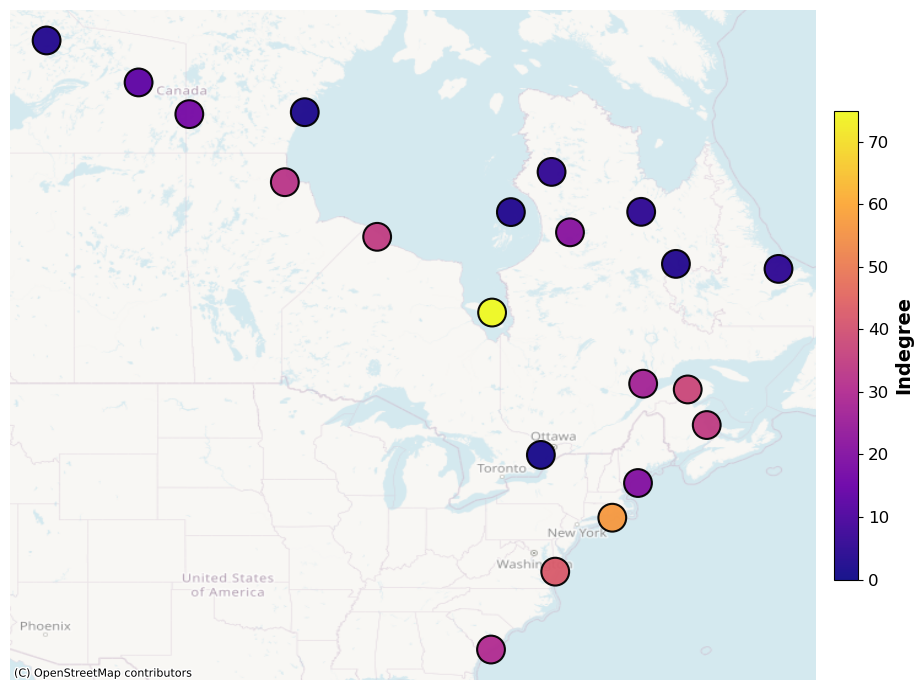


📍 Creazione mappa OUTDEGREE...

✓ Mappa di sfondo aggiunta!


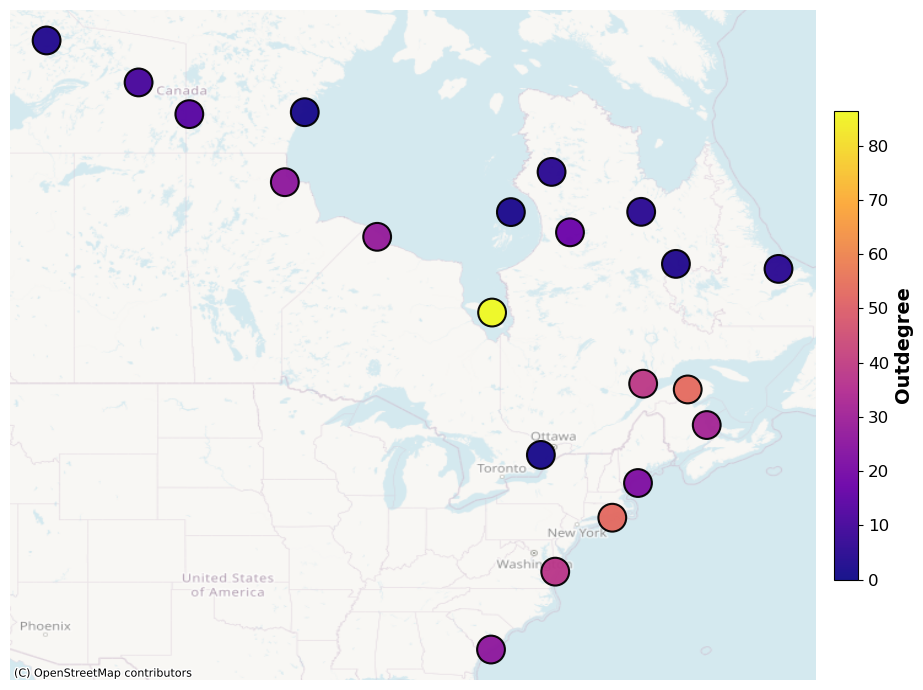

In [9]:
import matplotlib.pyplot as plt
import contextily as cx
from matplotlib.colors import LinearSegmentedColormap

def plot_degree_map(df, degree_df, metric='indegree'):
    """
    Mappa geografica con indegree o outdegree centrality
    
    Parameters:
    -----------
    df : DataFrame originale con centroids
    degree_df : DataFrame con indegree/outdegree
    metric : str - 'indegree' o 'outdegree'
    """
    
    # 1. Calcola coordinate medie per cluster
    cluster_coords = df.groupby('cluster').agg({
        'lat': 'mean',
        'lon': 'mean'
    }).reset_index()
    
    # 2. Merge con degree centrality
    cluster_data = cluster_coords.merge(degree_df, on='cluster')
    
    # 3. Converti in Web Mercator (come hai fatto prima)
    import numpy as np
    
    def lat_lon_to_web_mercator(lon, lat):
        """Converti lat/lon in Web Mercator"""
        x = lon * 20037508.34 / 180
        y = np.log(np.tan((90 + lat) * np.pi / 360)) / (np.pi / 180)
        y = y * 20037508.34 / 180
        return x, y
    
    x_coords = []
    y_coords = []
    for _, row in cluster_data.iterrows():
        x, y = lat_lon_to_web_mercator(row['lon'], row['lat'])
        x_coords.append(x)
        y_coords.append(y)
    
    cluster_data['x_web'] = x_coords
    cluster_data['y_web'] = y_coords
    
    # 4. Setup figura
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # 5. Colormap
    colors = ['#0D0887', '#6A00A8', '#B12A90', '#E16462', '#FCA636', '#F0F921']
    cmap = LinearSegmentedColormap.from_list('degree', colors, N=256)
    
    # 6. Plot punti
    values = cluster_data[metric].values
    
    scatter = ax.scatter(
        cluster_data['x_web'],
        cluster_data['y_web'],
        c=values,
        s=400,
        cmap=cmap,
        vmin=0,
        vmax=values.max(),
        edgecolors='black',
        linewidths=1.5,
        zorder=10,
        alpha=0.95
    )
    
    # 7. Mappa di sfondo
    try:
        cx.add_basemap(ax, source=cx.providers.OpenStreetMap.Mapnik, alpha=0.5, zorder=1)
        print("\n✓ Mappa di sfondo aggiunta!")
    except Exception as e:
        print(f"\nNota: Mappa non disponibile: {e}")
        ax.set_facecolor('#E8F4F8')
    
    # 8. Colorbar
    cbar = plt.colorbar(scatter, ax=ax, orientation='vertical', 
                        pad=0.02, shrink=0.7, aspect=20)
    label = 'Indegree' if metric == 'indegree' else 'Outdegree'
    cbar.set_label(label, fontsize=14, fontweight='bold')
    cbar.ax.tick_params(labelsize=12)
    

    
    # 10. Rimuovi assi
    ax.set_axis_off()
    
    plt.tight_layout()
    plt.show()


# Mappa INDEGREE
print("\n📍 Creazione mappa INDEGREE...")
plot_degree_map(df, degree_df, metric='indegree')

# Mappa OUTDEGREE
print("\n📍 Creazione mappa OUTDEGREE...")
plot_degree_map(df, degree_df, metric='outdegree')